# **Data inspection (weeks 1-4)**


In this notebook, wecheck that our two data sources can actually carry the pipeline, BEFORE we build on them. It maps directly to the premortem actions:

> "Trending skill" untestable / window too short, how many usable time points (months/quarters) `postings.csv` really has, and how evenly postings are spread (section 1).

> Kaggle quality, O*NET doesn't map onto postings, what Kaggle's own skill labels actually are and how many O*NET tech terms show up in real posting text (section 2, section 5).

> Role lookup, can a free-text role ("data scientist") be mapped to an O*NET occupation? (section 4).


NOTE:

Expected layout (see `data_repo_structue.txt`): run from `notebooks/` or the repo root; `data/` is gitignored.

### **Imports**



In [32]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Kaggle**

### **Data handling**

In [33]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

# definitions
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
DATA = ROOT / "data"
KAGGLE, ONET = DATA / "kaggle", DATA / "onet"

FILES = {
    # kaggle core files
    "postings":        KAGGLE / "postings.csv",
    "job_skills":      KAGGLE / "jobs" / "job_skills.csv",
    "skills_map":      KAGGLE / "mappings" / "skills.csv",
    # kagge tech industry files
    "job_industries":  KAGGLE / "jobs" / "job_industries.csv",
    "industries_map":  KAGGLE / "mappings" / "industries.csv",
    # O*NET core
    "software_skills": ONET / "software_skills.csv",
    "occupations":     ONET / "occupation_data.csv",
    "job_titles":      ONET / "job_titles.csv",
    # O*NET "reserve files" good to have
    "essential_skills":    ONET / "essential_skills.csv",
    "transferable_skills": ONET / "transferable_skills.csv",
    "related_occupations": ONET / "related_occupations.csv",
}

In [34]:
# loop
for name, path in FILES.items():
    status = f"{path.stat().st_size/1e6:7.1f} MB" if path.exists() else "  MISSING"
    print(f"{status}  {name:20s} {path.relative_to(ROOT)}")

  516.8 MB  postings             data/kaggle/postings.csv
    3.5 MB  job_skills           data/kaggle/jobs/job_skills.csv
    0.0 MB  skills_map           data/kaggle/mappings/skills.csv
    2.5 MB  job_industries       data/kaggle/jobs/job_industries.csv
    0.0 MB  industries_map       data/kaggle/mappings/industries.csv
    3.6 MB  software_skills      data/onet/software_skills.csv
    0.3 MB  occupations          data/onet/occupation_data.csv
    4.5 MB  job_titles           data/onet/job_titles.csv
    2.3 MB  essential_skills     data/onet/essential_skills.csv
    6.1 MB  transferable_skills  data/onet/transferable_skills.csv
    2.1 MB  related_occupations  data/onet/related_occupations.csv


In [35]:
# overview func
def overview(df, name):
    # One-glance summary: shape, dtypes, missingness, uniques
    print(f"── {name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_%": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(),
        "example": df.iloc[0] if len(df) else None,
    })

### **Section 1 | Kaggle `postings.csv` the MAIN table**

This is the file everything will be one, so the **text** (`title`, `description`, `skills_desc`) is where real skills like Docker/Python live, and `listed_time` / `original_listed_time` drive the trend analysis. Timestamps are in **milliseconds**.

In [36]:
postings = pd.read_csv(FILES["postings"])
postings

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an admini...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or Graduate Student (can also be ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with bes...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant ...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team i...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,This position requires a baseline understanding of online marketing includin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial e...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking an attorney to join our Title I...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,NaN,120000.0,Full-time,NaN,1.713571e+12,NaN,https://www.linkedin.com/jobs/view/3906267117/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.716163e+12,NaN,Mid-Senior level,NaN,1.713571e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,94595.0,6013.0
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across the world come to Pinterest to...,NaN,NaN,United States,1124131.0,3.0,NaN,NaN,Full-time,NaN,1.713572e+12,1.0,https://www.linkedin.com/jobs/view/3906267126/?trk=jobs_biz_prem_srch,https://www.pinterestcareers.com/en/jobs/5882432/staff-software-engineer-ml-...,OffsiteApply,1.716164e+12,NaN,Mid-Senior level,NaN,1.713572e+12,www.pinterestcareers.com,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading K–12 supplemental literacy and...,NaN,NaN,"Spokane, WA",90552133.0,3.0,NaN,NaN,Full-time,NaN,1.713572e+12,1.0,https://www.linkedin.com/jobs/view/3906267131/?trk=jobs_

In [37]:
# check duplicates and other basic checks
print("duplicate job_id:", postings["job_id"].duplicated().sum())
print("empty description:", postings["description"].isna().sum())
print("has skills_desc:", postings["skills_desc"].notna().mean().round(3) if "skills_desc" in postings else "column not present")
postings["description"].str.len().describe().round(0)

duplicate job_id: 0
empty description: 7
has skills_desc: 0.02


count    123842.0
mean       3766.0
std        2146.0
min           2.0
25%        2176.0
50%        3435.0
75%        4986.0
max       23201.0
Name: description, dtype: float64

##### **Time coverage inspired by *the* premortem check**

We claimed around 10K postings/month over 1 year, since we have 123849 postings in the dataset and the postings are from 2023-2024 (see https://www.kaggle.com/datasets/arshkon/linkedin-job-postings). This section is to check if Kaggle is true, because if postings cluster in a few weeks, quarter-over-quarter trends are not possible and we need to know early on.

In [38]:
for col in ["listed_time", "original_listed_time"]:
    postings[col + "_dt"] = pd.to_datetime(postings[col], unit="ms", errors="coerce")
    s = postings[col + "_dt"]
    print(f"{col:22s} min={s.min()}  max={s.max()}  missing={s.isna().sum()}")

listed_time            min=2024-03-24 21:50:14  max=2024-04-20 00:26:56  missing=0
original_listed_time   min=2023-12-05 21:08:53  max=2024-04-20 00:26:43  missing=0


Plot the timeline.

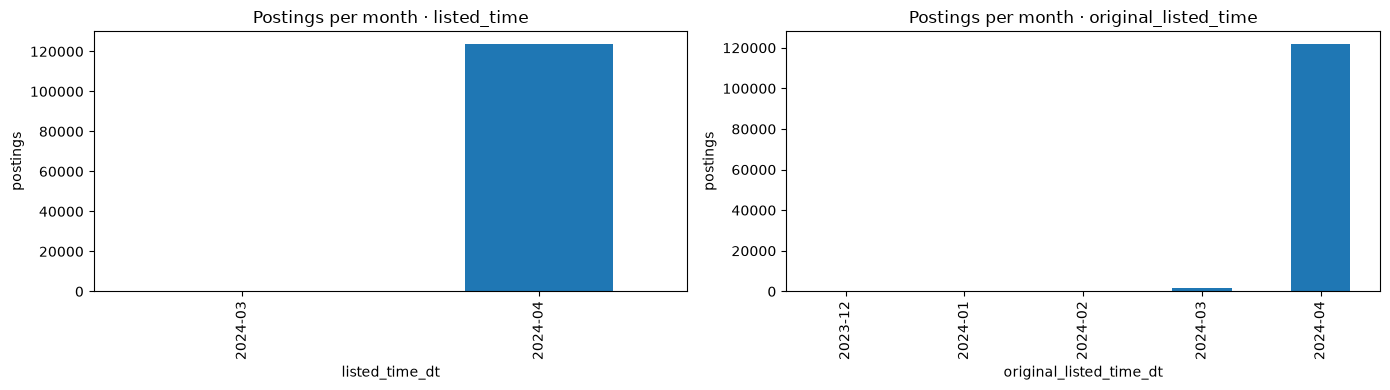

Postings per quarter (original_listed_time):
original_listed_time_dt
2023Q4         3
2024Q1      1831
2024Q2    122015
Freq: Q-DEC


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ["listed_time_dt", "original_listed_time_dt"]):
    monthly = postings[col].dt.to_period("M").value_counts().sort_index()
    monthly.plot(kind="bar", ax=ax)
    ax.set_title(f"Postings per month · {col.replace('_dt','')}")
    ax.set_ylabel("postings")
plt.tight_layout()
plt.show()

quarterly = postings["original_listed_time_dt"].dt.to_period("Q").value_counts().sort_index()
print("Postings per quarter (original_listed_time):")
print(quarterly.to_string())

2023-12         3
2024-01         7
2024-02         9
2024-03      1815
2024-04    122015
Freq: M, Name: count, dtype: int64


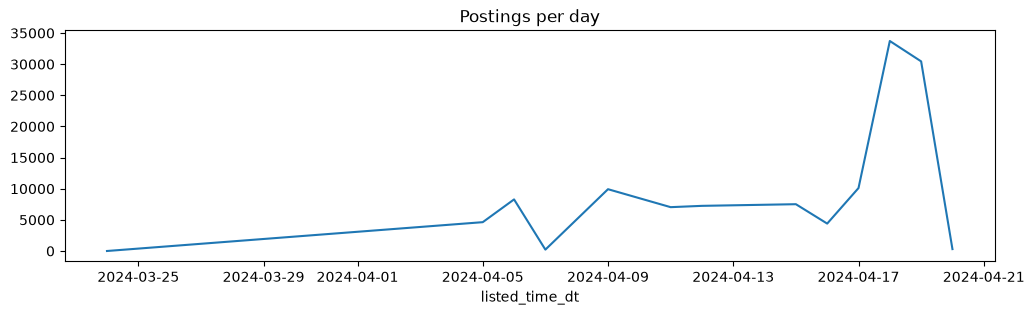

In [40]:
s = postings["original_listed_time_dt"]
months = s.dt.to_period("M").value_counts().reindex(
    pd.period_range(s.min(), s.max(), freq="M"), fill_value=0)
print(months)

postings["listed_time_dt"].dt.date.value_counts().sort_index().plot(figsize=(12, 3), title="Postings per day")
plt.show()

Many postings in march and april.

In [41]:
# type of jobs that dominate the data with top titles and experience levels
display(postings["title"].str.lower().value_counts().head(20))
if "formatted_experience_level" in postings:
    display(postings["formatted_experience_level"].value_counts(dropna=False))

title
sales manager                      673
customer service representative    480
project manager                    355
assistant store manager            320
administrative assistant           256
salesperson                        241
senior accountant                  239
executive assistant                232
registered nurse                   216
receptionist                       205
staff accountant                   201
account executive                  195
sales associate                    190
retail sales associate             190
store manager                      186
software engineer                  181
controller                         175
account manager                    171
senior software engineer           162
assistant manager                  161
Name: count, dtype: int64

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

In [42]:
# how many postings would a student-relevant role actually give us?
ROLE_PATTERNS = {
    "data scientist":    r"data scien",
    "data analyst":      r"data analy",
    "software engineer": r"software (?:engineer|developer)",
    "ml engineer":       r"(?:machine learning|ml) engineer",
    "ux designer":       r"(?:ux|ui|user experience).*design",
}
role_counts = {r: postings["title"].str.contains(p, case=False, regex=True, na=False).sum()
               for r, p in ROLE_PATTERNS.items()}
pd.Series(role_counts, name="n_postings").sort_values(ascending=False)

software engineer    1580
data analyst          467
data scientist        351
ux designer           161
ml engineer            99
Name: n_postings, dtype: int64

### **Section 2 | Kaggle `job_skills.csv` plus `mappings/skills.csv`**

Important finding: Kaggle's own "skills" are **only 35 broad job-function categories** (Information Technology, Sales, Engineering, …), 1-3 per posting. They are **not** tool-level skills like Docker or SQL. So they cannot produce the exact example we keep mentioning aka "Docker in 42% of postings" so that has to come from the posting text. They are still useful as a coarse role filter.

35 skill categories · 126,807 postings labelled
labels per posting: {1: 55149, 2: 56355, 3: 15303}
postings with NO label: 1753


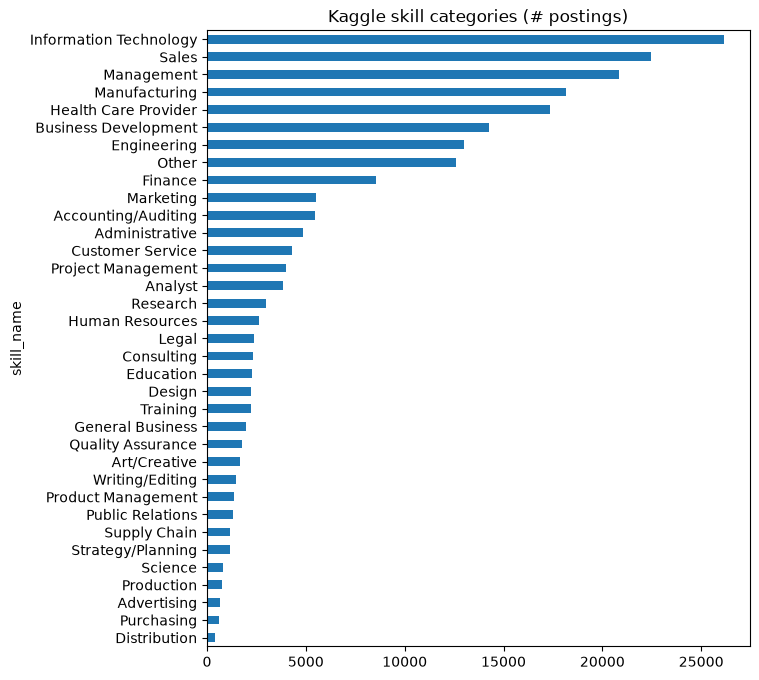

In [43]:
job_skills = pd.read_csv(FILES["job_skills"])
skills_map = pd.read_csv(FILES["skills_map"])
js = job_skills.merge(skills_map, on="skill_abr", how="left")

print(f"{len(skills_map)} skill categories · {job_skills['job_id'].nunique():,} postings labelled")
print("labels per posting:", job_skills.groupby("job_id").size().value_counts().sort_index().to_dict())
print("postings with NO label:", (~postings["job_id"].isin(job_skills["job_id"])).sum())
js["skill_name"].value_counts().plot(kind="barh", figsize=(7, 8), title="Kaggle skill categories (# postings)")
plt.gca().invert_yaxis(); plt.show()

### **Section 3 |Industries (maybe) is a tech filter worth it?**

In [44]:
job_ind = pd.read_csv(FILES["job_industries"]).merge(pd.read_csv(FILES["industries_map"]), on="industry_id", how="left")
print("unmatched industry_id:", job_ind["industry_name"].isna().sum())
job_ind["industry_name"].value_counts().head(20)

unmatched industry_id: 100


industry_name
Hospitals and Health Care             18326
Retail                                11033
IT Services and IT Consulting         10396
Staffing and Recruiting                9005
Financial Services                     8535
Software Development                   5091
Manufacturing                          3689
Construction                           3445
Banking                                2923
Insurance                              2673
Pharmaceutical Manufacturing           2469
Hospitality                            2455
Telecommunications                     2433
Real Estate                            2326
Industrial Machinery Manufacturing     2143
Non-profit Organizations               2063
Biotechnology Research                 2005
Accounting                             1968
Motor Vehicle Manufacturing            1951
Food and Beverage Services             1880
Name: count, dtype: int64

# **O*NET**

Investigating O*NET data.

### **Section 4 | O*NET occupations, job titles, software skills**

> `occupation_data.csv`: 1,016 occupations (SOC code → title/description)

> `job_titles.csv`: around 54K alternate titles → our free-text role lookup

> `software_skills.csv` (O*NET "Technology Skills"): specific tools per occupation, with `Hot Technology` / `In Demand` flags. `Workplace Example` = the tool, `Element Name` = its category.

In [45]:
occupations = pd.read_csv(FILES["occupations"])
job_titles  = pd.read_csv(FILES["job_titles"])
software    = pd.read_csv(FILES["software_skills"])

display(overview(software, "software_skills"))
print("distinct tools:", software["Workplace Example"].nunique(),
      "· categories:", software["Element Name"].nunique(),
      "· occupations covered:", software["O*NET-SOC Code"].nunique(), "of", len(occupations))
print("Hot Technology share:", (software["Hot Technology"] == "Y").mean().round(3),
      "· In Demand share:", (software["In Demand"] == "Y").mean().round(3))

── software_skills: 31,821 rows × 7 cols


,dtype,missing_%,n_unique,example
O*NET-SOC Code,str,0.0,923,11-1011.00
Title,str,0.0,923,Chief Executives
Workplace Example,str,0.0,8753,Adobe Acrobat
Element ID,str,0.0,134,2.E.5.b
Element Name,str,0.0,134,Document management software
Hot Technology,str,0.0,2,Y
In Demand,str,0.0,2,N


distinct tools: 8753 · categories: 134 · occupations covered: 923 of 1016
Hot Technology share: 0.364 · In Demand share: 0.076


In [46]:
def find_occupation(role: str, top=5):
    # Free-text role -> candidate O*NET occupations via alternate job titles
    hits = job_titles[job_titles["Job Title"].str.contains(role, case=False, na=False)]
    return (hits.groupby(["O*NET-SOC Code", "Title"]).size()
                .sort_values(ascending=False).head(top).rename("matching_titles"))

for role in ["data scientist", "software engineer", "ux designer"]:
    print(f"\n'{role}':"); display(find_occupation(role))


'data scientist':


O*NET-SOC Code  Title                                       
15-2051.00      Data Scientists                                 2
15-1221.00      Computer and Information Research Scientists    1
15-1299.05      Information Security Engineers                  1
51-8099.01      Biofuels Processing Technicians                 1
Name: matching_titles, dtype: int64


'software engineer':


O*NET-SOC Code  Title                                    
15-1252.00      Software Developers                          8
15-1254.00      Web Developers                               3
15-1299.07      Blockchain Engineers                         2
15-1299.08      Computer Systems Engineers/Architects        2
11-3021.00      Computer and Information Systems Managers    1
Name: matching_titles, dtype: int64


'ux designer':


O*NET-SOC Code  Title                                          
15-1253.00      Software Quality Assurance Analysts and Testers    2
15-1255.00      Web and Digital Interface Designers                1
Name: matching_titles, dtype: int64

In [47]:
def tools_for(soc_code):
    t = software[software["O*NET-SOC Code"] == soc_code]
    return t[["Workplace Example", "Element Name", "Hot Technology", "In Demand"]].sort_values(
        ["In Demand", "Hot Technology"], ascending=False)

tools_for("15-2051.00").head(25)   # Data Scientists

,Workplace Example,Element Name,Hot Technology,In Demand
11870,Amazon Web Services AWS software,Data base user interface and query software,Y,Y
11873,Apache Hadoop,Data base management system software,Y,Y
11878,Apache Spark,Business intelligence and data analysis software,Y,Y
11886,C++,Object or component oriented development software,Y,Y
11891,Git,File versioning software,Y,Y
11910,Microsoft Azure software,Development environment software,Y,Y
11911,Microsoft Excel,Spreadsheet software,Y,Y
11913,Microsoft Power BI,Business intelligence and data analysis software,Y,Y
11914,Microsoft PowerPoint,Presentation software,Y,Y
11927,Python,Object or component oriented development software,Y,Y


Notice the naming: O*NET writes e.g. *"Structured query language SQL"*, *"Amazon Web Services AWS software"*. Nobody writes that in a job ad and this is exactly the matching problem from the premortem.

### **Section 5 | Coverage check, do O*NET tools actually appear in posting text?**

A first, deliberately simple **keyword baseline** (our fallback from the premortem). For each O*NET tool we generate a few aliases (full name, name without "software", trailing acronyms like `SQL`, `AWS`) and search posting descriptions on a sample. Two numbers matter:

1. % of postings where we find **≥1 tool** (can we build a skill vector at all?)
2. which tools are found most → sanity check against intuition

In [48]:
#     (1) vocabulary = tools O*NET flags Hot Technology / In Demand (what employers actually ask for)
#     (2) drop generic category entries ("Payroll software")      
#    (3) strip vendor names ("Microsoft Power BI" → "Power BI")
#     (4) acronyms only when they abbreviate the words before them ("Structured query language SQL" → "SQL")
#     (5) case-sensitive matching for tool names that are also English words ("R", "Go", "Excel", "Spark")
#     (6) print any alias that fires in >10% of all postings, and drop it

flags = software.groupby("Workplace Example")[["Hot Technology", "In Demand"]].agg(lambda s: (s == "Y").any())
important = set(flags.index[flags["Hot Technology"] | flags["In Demand"]])
popularity = software["Workplace Example"].value_counts()

KEEP = {"Rust programming language": "Rust", "ANSYS simulation software": "ANSYS", "Shell script": "Shell scripting"}
def is_generic(name: str) -> bool:
    if name in KEEP: return False
    words = re.sub(r"\s+(software|systems?|tools)$", "", name, flags=re.I).split()
    return (len(words) > 1 and all(w.islower() for w in words[1:])) or \
           (len(words) == 1 and words[0].lower() in {"tax", "payroll", "productivity", "reporting", "purchasing",
                                                     "statistical", "chatbot", "disassembler", "firewall"})
VOCAB = sorted(t for t in important if not is_generic(t))
print(f"{len(important)} hot/in-demand tools → {len(VOCAB)} after dropping generic entries")

VENDORS = ["Microsoft", "Apache", "Amazon", "Google", "Adobe", "Autodesk", "Atlassian", "Oracle", "IBM", "ESRI",
           "Intuit", "Apple", "The MathWorks", "MathWorks", "Red Hat", "Dassault Systemes", "StataCorp", "SAS"]
NO_SHORT = {"analytics", "docs", "meet", "sheets", "ads", "project", "word", "access", "edge", "teams",
            "windows", "office", "azure", "workforce now", "cloud", "database",
            "workspace", "android", "ios", "macos"}          # too ambiguous without the vendor name
CASE_SENSITIVE = {"C", "R", "Go", "Swift", "React", "Ruby", "Chef", "Puppet", "Slack", "Zoom", "Bootstrap",
                  "Prometheus", "Snowflake", "Google", "Facebook", "Bash", "Scala", "Rust", "Excel", "Spark",
                  "Hive", "Outlook", "Safari", "Unity", "REST Assured", "Selenium", "Postman", "Swift"}

def is_abbrev(acr: str, words: list[str]) -> bool:
    # True if acr's letters start with, and contain in order, the initials of the words before it
    for k in range(len(words), 1, -1):
        init = "".join(w[0].upper() for w in words[-k:])
        it = iter(acr.upper())
        if init[0] == acr[0] and all(c in it for c in init): return True
    return False

def aliases(name: str) -> set[str]:
    out = {name, KEEP.get(name, name)}
    core = re.sub(r"\s+software$", "", name, flags=re.I)
    out.add(core)                                                    # "Salesforce software" → "Salesforce"
    for v in VENDORS:                                                # "Microsoft Power BI" → "Power BI"
        if core.startswith(v + " ") and core[len(v) + 1:].lower() not in NO_SHORT:
            out.add(core[len(v) + 1:])
    words = core.split()
    if len(words) > 2 and re.fullmatch(r"[A-Z][A-Z0-9+#]{1,5}", words[-1]) and is_abbrev(words[-1], words[:-1]):
        out.add(words[-1])                                           # "... language SQL" → "SQL"
    return out

TOKEN = re.compile(r"[A-Za-z0-9+#&]+(?:[.-][A-Za-z0-9+#&]+)*")      # keeps C++, C#, Node.js, R&D (so "R" ≠ R&D)
def tokens(text: str) -> list[str]:
    return TOKEN.findall(text)

alias_to_tool = {}                        # key = lowercased n-gram, or exact-case n-gram for CASE_SENSITIVE names
for t in sorted(VOCAB, key=lambda t: popularity.get(t, 0)):          # more popular tool wins a shared alias
    for a in aliases(t):
        toks = tokens(a)
        if toks:
            alias_to_tool[" ".join(toks) if a in CASE_SENSITIVE else " ".join(toks).lower()] = t
MAX_N = min(max(len(k.split()) for k in alias_to_tool), 8)

def extract_aliases(text: str) -> set[str]:
    if not isinstance(text, str): return set()
    toks = tokens(text); low = [w.lower() for w in toks]
    found = set()
    for n in range(1, MAX_N + 1):
        for i in range(len(toks) - n + 1):
            for g in (" ".join(low[i:i + n]), " ".join(toks[i:i + n])):
                if g in alias_to_tool: found.add(g)
    return found

# Safety net: an alias that fires in >10% of ALL postings is probably an English word, not a skill
probe = postings["description"].dropna().sample(3000, random_state=0).map(extract_aliases)
share = probe.explode().value_counts() / len(probe)
print("aliases firing in >10% of postings (dropped — review):",
      share[share > 0.10].round(3).to_dict() or "none")
for a in share[share > 0.10].index: alias_to_tool.pop(a, None)

def extract_tools(text: str) -> set[str]:
    return {alias_to_tool[a] for a in extract_aliases(text) if a in alias_to_tool}

print(f"{len(VOCAB)} tools → {len(alias_to_tool)} aliases")
print("sanity:", sorted(extract_tools("Python, SQL, R, Power BI, Excel, AWS, Docker, Git/GitHub. R&D team; excel at "
                                      "communication; rest assured; ERP and BI reporting.")))

331 hot/in-demand tools → 301 after dropping generic entries
aliases firing in >10% of postings (dropped — review): {'Excel': 0.124}
301 tools → 449 aliases
sanity: ['Amazon Web Services AWS software', 'Docker', 'Git', 'GitHub', 'Microsoft Power BI', 'Python', 'R', 'Structured query language SQL']


In [49]:
SAMPLE_N = 5000   # the full ~124K should also run in a few minutes once you trust it
sample = postings.sample(min(SAMPLE_N, len(postings)), random_state=42).copy()
sample["tools"] = (sample["title"].fillna("") + " " + sample["description"].fillna("")).map(extract_tools)
sample["n_tools"] = sample["tools"].map(len)

print(f"postings with ≥1 tool: {(sample['n_tools'] > 0).mean():.1%}")
print(sample["n_tools"].describe().round(1))

tool_freq = sample.explode("tools")["tools"].value_counts()
print(f"\ndistinct O*NET tools seen: {len(tool_freq)} of {len(tool_names):,}")
tool_freq.head(30)

postings with ≥1 tool: 38.4%
count    5000.0
mean        1.0
std         2.0
min         0.0
25%         0.0
50%         0.0
75%         1.0
max        34.0
Name: n_tools, dtype: float64

distinct O*NET tools seen: 210 of 8,753


tools
Microsoft Office software           467
Microsoft PowerPoint                247
Microsoft Outlook                   206
Structured query language SQL       204
Python                              175
Google                              138
Amazon Web Services AWS software    113
Oracle Java                         111
SAP software                        107
Facebook                             97
JavaScript                           89
Salesforce software                  87
Workday software                     85
Microsoft Excel                      76
C                                    76
Microsoft Word                       76
Hypertext markup language HTML       67
Go                                   66
Atlassian JIRA                       64
Linux                                63
R                                    62
Kubernetes                           58
Cascading style sheets CSS           53
Autodesk AutoCAD                     49
C#                                

In [50]:
# Eyeball a few postings: does the extraction look right? (precision check by hand)
for _, row in sample[sample["n_tools"] > 0].head(3).iterrows():
    print("TITLE:", row["title"]); print("TOOLS:", sorted(row["tools"])); print("-" * 80)

TITLE: Senior Automation Engineer - Power Systems
TOOLS: ['Autodesk AutoCAD']
--------------------------------------------------------------------------------
TITLE: Mountain Multimedia Journalist, KMGH
TOOLS: ['Apple Final Cut Pro']
--------------------------------------------------------------------------------
TITLE: Java Architect
TOOLS: ['Kubernetes', 'Microsoft SQL Server', 'Oracle Java', 'Spring Boot', 'Structured query language SQL']
--------------------------------------------------------------------------------


> **Things to note for the report / next week:** false positives (ambiguous short names), obvious misses (e.g. "Docker", "PyTorch", "Tableau" written differently than in O*NET), and whether coverage is much better for tech titles than for all postings. This is our baseline number for the keyword-vs-taxonomy study (weeks 9–10).

### **Section 6 | Reserve files (quick look only)**

`essential_skills.csv` / `transferable_skills.csv` are O*NET's general skill ratings per occupation, on two scales: `IM` (importance, 1-5) and `LV` (level, 0-7). Only relevant if we add a "broader skill area" view later.

In [51]:
essential = pd.read_csv(FILES["essential_skills"])
print("scales:", essential["Scale ID"].unique(), "· skills:", essential["Element Name"].nunique())
imp = (essential[essential["Scale ID"] == "IM"]
       .pivot(index="Title", columns="Element Name", values="Data Value"))
imp.loc["Data Scientists"].sort_values(ascending=False).head(10)

scales: <StringArray>
['IM', 'LV']
Length: 2, dtype: str · skills: 10


Element Name
Mathematics              4.38
Critical Thinking        4.25
Reading Comprehension    3.88
Active Learning          3.62
Speaking                 3.62
Active Listening         3.50
Writing                  3.50
Monitoring               3.25
Learning Strategies      2.75
Science                  2.50
Name: Data Scientists, dtype: float64

### **Findings towards decisions**

| Question | Finding | Decision / next step |
|---|---|---|
| How many usable time buckets? | One: a single scrape, Mar 24 – Apr 20 2024, 98.5% in April. Only 19 postings first listed before March | No time series within this dataset. Use it as the "April" snapshot |
| Enough postings for our target roles? | SE 1,580 · DA 467 · DS 351 · UX 161 · ML 99 | Enough for SE, DA and DS; too few for UX and ML alone. Use as replication and entry-level set |
| Kaggle skill labels usable? | Only 35 broad categories | Use text extraction with O*NET vocabulary; categories only as role filter |
| O*NET coverage in posting text (keyword baseline) | 38.4% of *all* postings have ≥1 tool (median 0). Expected, since most postings are sales, nursing, admin. The top tools look right (MS Office, SQL, Python, AWS, Java) | Report coverage per target role, not over all postings. This is the baseline number for weeks 9–10 |
| Worst alias problems | v1 matched English words ("or", "dental") → fixed by restricting to O*NET hot/in-demand tools. Still suspicious: "Google" (138), "Facebook" (97), "C" (76), "Go" (66) | Spot-check these four; move to `MANUAL_DROP` or require more context |
